# Solar Forecast Utility — Example Notebook

This notebook demonstrates the two public functions exported from `utils/solar_utils.py`.

| Function | What it does |
|---|---|
| `load_solar_config(config_path)` | Read and validate `user_config.json` |
| `get_daily_solar_kwh(target_date, mode, config_path, allow_fallback)` | Return a 96-row, 15-min UTC forecast for one day |

**Output columns** from `get_daily_solar_kwh`:
- `time` – UTC timestamp (timezone-aware)
- `predicted_kwh` – energy per 15-min slot (kWh)
- `predicted_kw` – mean power per slot (kW)
- `temperature_2m` – ambient temperature (°C)
- `source` – `forecast_api` | `historical_api` | `clear_sky_fallback`

> Run from **project root** so `user_config.json` is found on the default path.

## 1. System configuration

`load_solar_config()` reads `user_config.json`, validates the six required keys, and returns them as `float`.

Required keys: `lat`, `lon`, `kwp`, `tilt`, `azimuth`, `yield_factor`.

In [4]:
import sys
from pathlib import Path

# Ensure notebook imports resolve from project root and src/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"

for p in (PROJECT_ROOT, SRC_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from utils.solar_utils import load_solar_config

config = load_solar_config()   # default path: user_config.json
print("Config keys and values:")
for key, val in config.items():
    print(f"  {key:>14}: {val}")

Config keys and values:
             lat: 47.659216
             lon: 9.1750718
             kwp: 20.0
            tilt: 35.0
         azimuth: 0.0
    yield_factor: 0.7


## 2. Calling `get_daily_solar_kwh`

```python
get_daily_solar_kwh(
    target_date    = None,               # date | str 'YYYY-MM-DD' | datetime  — default: tomorrow
    mode           = "auto",             # "auto" | "forecast" | "historical"
    config_path    = "user_config.json",
    allow_fallback = True,               # use clear-sky model if API is unreachable
)
```

`mode="auto"` selects the API automatically:
- **past date** → `historical_api` (Open-Meteo archive, hourly → interpolated to 15-min)
- **today / future** → `forecast_api` (Open-Meteo forecast, native 15-min)

If the API is unreachable and `allow_fallback=True`, a geometric clear-sky estimate is used instead — `source` will read `clear_sky_fallback`. The output shape is **always 96 rows × 5 columns**.

In [5]:
from utils.solar_utils import get_daily_solar_kwh

# Default call: tomorrow (mode='auto' → forecast)
tomorrow = get_daily_solar_kwh()
print(f"Date  : {tomorrow['time'].dt.date.iloc[0]}")
print(f"Rows  : {len(tomorrow)}")
print(f"Source: {tomorrow['source'].iloc[0]}")
print()
tomorrow.head(8)

Date  : 2026-04-22
Rows  : 96
Source: forecast_api



,time,predicted_kwh,predicted_kw,temperature_2m,source
0,2026-04-22 00:00:00+00:00,0.0,0.0,7.6,forecast_api
1,2026-04-22 00:15:00+00:00,0.0,0.0,7.5,forecast_api
2,2026-04-22 00:30:00+00:00,0.0,0.0,7.4,forecast_api
3,2026-04-22 00:45:00+00:00,0.0,0.0,7.2,forecast_api
4,2026-04-22 01:00:00+00:00,0.0,0.0,7.1,forecast_api
5,2026-04-22 01:15:00+00:00,0.0,0.0,7.0,forecast_api
6,2026-04-22 01:30:00+00:00,0.0,0.0,6.9,forecast_api
7,2026-04-22 01:45:00+00:00,0.0,0.0,6.8,forecast_api


In [6]:
# Explicit historical date (mode='auto' → historical)
past = get_daily_solar_kwh(target_date="2021-06-21")
print(f"Date  : {past['time'].dt.date.iloc[0]}")
print(f"Source: {past['source'].iloc[0]}")
print()
past.head(8)

Date  : 2021-06-21
Source: historical_api



,time,predicted_kwh,predicted_kw,temperature_2m,source
0,2021-06-21 00:00:00+00:00,0.0,0.0,18.00,historical_api
1,2021-06-21 00:15:00+00:00,0.0,0.0,17.85,historical_api
2,2021-06-21 00:30:00+00:00,0.0,0.0,17.70,historical_api
3,2021-06-21 00:45:00+00:00,0.0,0.0,17.55,historical_api
4,2021-06-21 01:00:00+00:00,0.0,0.0,17.40,historical_api
5,2021-06-21 01:15:00+00:00,0.0,0.0,17.35,historical_api
6,2021-06-21 01:30:00+00:00,0.0,0.0,17.30,historical_api
7,2021-06-21 01:45:00+00:00,0.0,0.0,17.25,historical_api


In [7]:
from datetime import date, timedelta

# Explicit future date
future_date = (date.today() + timedelta(days=5)).isoformat()
future = get_daily_solar_kwh(target_date=future_date)
print(f"Date  : {future['time'].dt.date.iloc[0]}")
print(f"Source: {future['source'].iloc[0]}")
print()
future.head(8)

Date  : 2026-04-26
Source: forecast_api



,time,predicted_kwh,predicted_kw,temperature_2m,source
0,2026-04-26 00:00:00+00:00,0.0,0.0,8.7,forecast_api
1,2026-04-26 00:15:00+00:00,0.0,0.0,8.5,forecast_api
2,2026-04-26 00:30:00+00:00,0.0,0.0,8.2,forecast_api
3,2026-04-26 00:45:00+00:00,0.0,0.0,8.0,forecast_api
4,2026-04-26 01:00:00+00:00,0.0,0.0,7.8,forecast_api
5,2026-04-26 01:15:00+00:00,0.0,0.0,7.6,forecast_api
6,2026-04-26 01:30:00+00:00,0.0,0.0,7.4,forecast_api
7,2026-04-26 01:45:00+00:00,0.0,0.0,7.2,forecast_api


In [8]:
# allow_fallback behaviour
# True  (default) → never raises; source='clear_sky_fallback' signals the fallback was used
# False           → raises if the API is unreachable

# Forcing a fallback by passing a non-existent config is not needed in normal use.
# The source column in any result always tells you which path was taken.
print("allow_fallback=True  → always returns 96 rows; source reflects what was used")
print("allow_fallback=False → raises if the API is unreachable")
print()
print("Sources you may see:")
for s in ["forecast_api", "historical_api", "clear_sky_fallback"]:
    print(f"  {s}")

allow_fallback=True  → always returns 96 rows; source reflects what was used
allow_fallback=False → raises if the API is unreachable

Sources you may see:
  forecast_api
  historical_api
  clear_sky_fallback


## 3. EDA — output structure

Exploring the DataFrame returned by `get_daily_solar_kwh` using the historical date as a deterministic reference.

In [9]:
df = past.copy()

print("Shape:", df.shape)
print()
print("dtypes:")
print(df.dtypes)
print()
df.describe()

Shape: (96, 5)

dtypes:
time              datetime64[ns, UTC]
predicted_kwh                 float64
predicted_kw                  float64
temperature_2m                float64
source                         object
dtype: object



,predicted_kwh,predicted_kw,temperature_2m
count,96.000000,96.000000,96.000000
mean,0.903407,3.613619,20.296979
std,1.046738,4.186956,2.785116
min,0.000000,0.000000,17.000000
25%,0.000000,0.000000,17.800000
50%,0.347150,1.388400,19.310000
75%,1.741300,6.965225,23.250000
max,2.947000,11.788000,25.200000


In [10]:
daylight = df[df["predicted_kw"] > 0]
peak_idx = df["predicted_kw"].idxmax()

print(f"Total rows      : {len(df)}  (always 96 – one full UTC day)")
print(f"Daylight slots  : {len(daylight)}")
print(f"Total energy    : {df['predicted_kwh'].sum():.3f} kWh")
print(f"Peak power      : {df['predicted_kw'].max():.3f} kW")
print(f"Peak time (UTC) : {df.loc[peak_idx, 'time']}")
print(f"Temp range      : {df['temperature_2m'].min():.1f} – {df['temperature_2m'].max():.1f} °C")

Total rows      : 96  (always 96 – one full UTC day)
Daylight slots  : 71
Total energy    : 86.727 kWh
Peak power      : 11.788 kW
Peak time (UTC) : 2021-06-21 13:00:00+00:00
Temp range      : 17.0 – 25.2 °C


## 4. Daily production profile

15-min `predicted_kw` across the full UTC day (orange, left axis) with ambient temperature overlaid (blue dashed, right axis).

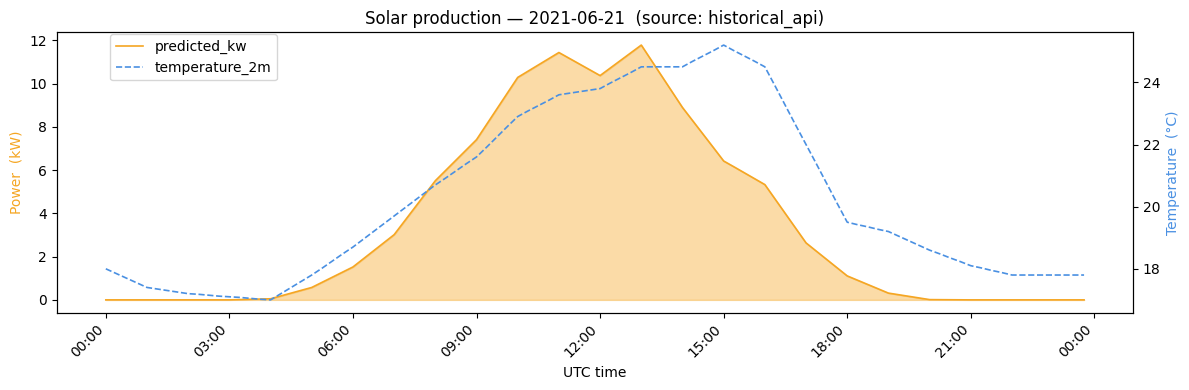

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.fill_between(df["time"], df["predicted_kw"], alpha=0.4, color="#f5a623")
ax1.plot(df["time"], df["predicted_kw"], color="#f5a623", linewidth=1.2, label="predicted_kw")
ax1.set_ylabel("Power  (kW)", color="#f5a623")
ax1.set_xlabel("UTC time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(df["time"], df["temperature_2m"], color="#4a90e2", linewidth=1.2,
         linestyle="--", label="temperature_2m")
ax2.set_ylabel("Temperature  (°C)", color="#4a90e2")

day_str = str(df["time"].dt.date.iloc[0])
src_str = df["source"].iloc[0]
ax1.set_title(f"Solar production — {day_str}  (source: {src_str})")
fig.legend(loc="upper left", bbox_to_anchor=(0.09, 0.92))
fig.tight_layout()
plt.show()

## 5. Seasonal comparison

Overlay a summer and a winter day to see how location and season affect daily production.

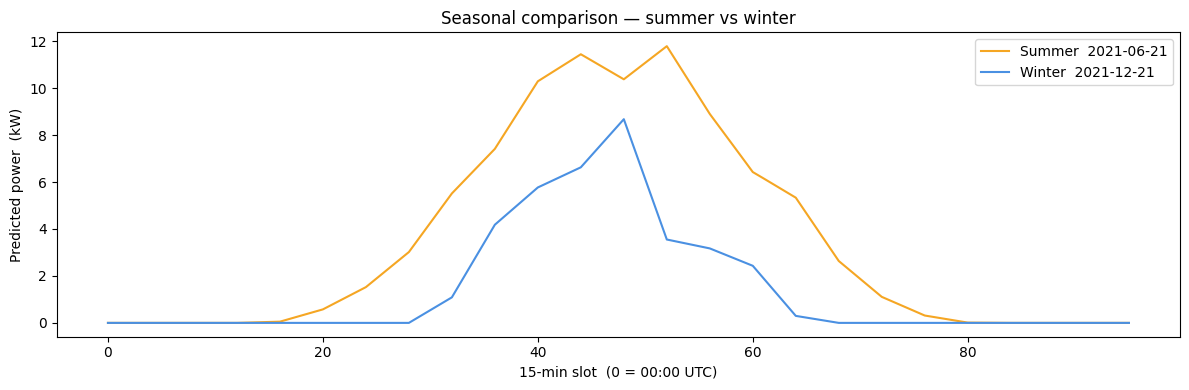

Summer total: 86.73 kWh
Winter total: 35.80 kWh
Ratio       : 2.4×


In [12]:
summer = get_daily_solar_kwh(target_date="2021-06-21", mode="historical")
winter = get_daily_solar_kwh(target_date="2021-12-21", mode="historical")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(96), summer["predicted_kw"], label="Summer  2021-06-21", color="#f5a623")
ax.plot(range(96), winter["predicted_kw"],  label="Winter  2021-12-21", color="#4a90e2")
ax.set_xlabel("15-min slot  (0 = 00:00 UTC)")
ax.set_ylabel("Predicted power  (kW)")
ax.set_title("Seasonal comparison — summer vs winter")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Summer total: {summer['predicted_kwh'].sum():.2f} kWh")
print(f"Winter total: {winter['predicted_kwh'].sum():.2f} kWh")
print(f"Ratio       : {summer['predicted_kwh'].sum() / winter['predicted_kwh'].sum():.1f}×")